In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from scipy.spatial import ConvexHull

try:
  from google.colab.data_table import DataTable
  DataTable.max_columns = 40
except:
  pass

!pip install adjustText
from adjustText import adjust_text

The steps taken in the Data Collection and Cleaning section are stored in "2025 data final.csv" so you can skip that section and simply load the .csv below!

In [143]:
data = pd.read_csv("2025 data final.csv").set_index("Player")
data

,PTS,AST,ORB,DRB,STL,BLK,TOV,FGA,3PA,FTA,...,DBPM,0-3 % of FGA,10-16 % of FGA,3P % of FGA,0-3 FG%,10-16 FG%,% of 2P Ast’d,% of 3P Ast’d,Dunks %FGA,3PA% Corner
Player,,,,,,,,,,,,,,,,,,,,,
Mikal Bridges,23.6,5.0,1.2,3.1,1.2,0.7,2.2,19.3,7.6,1.9,...,-0.9,0.185,0.192,0.391,0.785,0.507,0.682,0.957,0.025,0.449
Josh Hart,18.0,7.8,2.8,9.9,2.0,0.5,2.7,13.2,4.3,3.5,...,1.8,0.408,0.066,0.327,0.732,0.412,0.613,0.869,0.030,0.258
Anthony Edwards,37.4,6.2,1.0,6.7,1.6,0.9,4.3,27.7,13.9,8.5,...,0.0,0.176,0.084,0.503,0.678,0.341,0.384,0.475,0.039,0.107
Devin Booker,34.0,9.4,1.3,4.1,1.2,0.3,3.9,25.1,9.7,8.5,...,-2.4,0.109,0.206,0.388,0.690,0.531,0.431,0.716,0.013,0.123
James Harden,31.8,12.1,1.0,7.1,2.1,1.0,6.0,22.9,11.8,10.2,...,0.8,0.106,0.122,0.516,0.657,0.405,0.176,0.370,0.003,0.042
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Elfrid Payton,8.1,15.8,1.4,6.1,2.3,1.0,5.6,11.6,0.6,0.7,...,-1.3,0.148,0.262,0.049,0.333,0.250,0.179,1.000,0.000,0.167
Colin Castleton,13.7,3.1,5.9,7.7,0.9,1.1,2.6,10.9,1.8,4.2,...,-1.0,0.337,0.112,0.163,0.697,0.455,0.682,1.000,0.102,0.563
Jalen Hood-Schifino,16.6,5.8,0.5,3.8,0.8,1.1,2.8,15.3,7.2,3.3,...,-2.5,0.071,0.194,0.469,0.571,0.526,0.304,0.571,0.000,0.109


# Data Collection and Cleaning

In [39]:
def load_and_process(filepath, cols):
    df = pd.read_csv(filepath)

    # Filter traded rows
    player_counts = df["Player"].value_counts()
    traded_players = player_counts[player_counts > 1].index
    single_team_rows = df[~df["Player"].isin(traded_players)]
    combined_rows = df[(df["Player"].isin(traded_players)) & (df["Team"].str.contains("TM"))]
    filtered = pd.concat([single_team_rows, combined_rows], ignore_index=True)

    # Set index to player names
    filtered = filtered[cols].set_index("Player").drop("Team", axis = 1)
    return filtered

In [29]:
# Columns to use
per100_cols = ["Player", "Team", "PTS", "AST", "ORB", "DRB", "STL", "BLK", "TOV", "FGA", "3PA", "FTA", "eFG%", "FG%", "3P%", "FT%", "G", "MP"]
advanced_cols = ["Player", "Team", "TS%", "USG%", "AST%", "ORB%", "DRB%", "STL%", "BLK%", "TOV%","3PAr", "FTr", "OBPM", "DBPM"]
shooting_cols = ["Player", "Team", "0-3 % of FGA", "10-16 % of FGA", "3P % of FGA", "0-3 FG%", "10-16 FG%", "% of 2P Ast’d", "% of 3P Ast’d", "Dunks %FGA", "3PA% Corner"]

# Load and process each csv
per100 = load_and_process("b-ref per100.csv", per100_cols)
advanced = load_and_process("b-ref advanced.csv", advanced_cols)
shooting = load_and_process("b-ref shooting.csv", shooting_cols)

# Combine
data = pd.concat([per100, advanced, shooting], axis=1, join='inner')
data.head()

,PTS,AST,ORB,DRB,STL,BLK,TOV,FGA,3PA,FTA,...,DBPM,0-3 % of FGA,10-16 % of FGA,3P % of FGA,0-3 FG%,10-16 FG%,% of 2P Ast’d,% of 3P Ast’d,Dunks %FGA,3PA% Corner
Player,,,,,,,,,,,,,,,,,,,,,
Mikal Bridges,23.6,5.0,1.2,3.1,1.2,0.7,2.2,19.3,7.6,1.9,...,-0.9,0.185,0.192,0.391,0.785,0.507,0.682,0.957,0.025,0.449
Josh Hart,18.0,7.8,2.8,9.9,2.0,0.5,2.7,13.2,4.3,3.5,...,1.8,0.408,0.066,0.327,0.732,0.412,0.613,0.869,0.030,0.258
Anthony Edwards,37.4,6.2,1.0,6.7,1.6,0.9,4.3,27.7,13.9,8.5,...,0.0,0.176,0.084,0.503,0.678,0.341,0.384,0.475,0.039,0.107
Devin Booker,34.0,9.4,1.3,4.1,1.2,0.3,3.9,25.1,9.7,8.5,...,-2.4,0.109,0.206,0.388,0.690,0.531,0.431,0.716,0.013,0.123
James Harden,31.8,12.1,1.0,7.1,2.1,1.0,6.0,22.9,11.8,10.2,...,0.8,0.106,0.122,0.516,0.657,0.405,0.176,0.370,0.003,0.042


In [30]:
data.shape

(569, 37)

In [31]:
# Create the filter mask: 15 minutes/game, at least 10 games played, at least 5 points
mask = ((data['MP'] / data['G']) >= 15) & (data['G'] >= 10) & (data['PTS'] >= 5)
# mask = ((data['MP'] / data['G']) >= 25) & (data['G'] >= 40) & (data['PTS'] >= 10)

# Get list of removed player names
removed_players = data[~mask].index.tolist()

# Apply the filter
data = data[mask]

# Print how many and who
print(f"Removed {len(removed_players)} players:")
for name in removed_players:
    print(name)

Removed 217 players:
Julian Phillips
Dalen Terry
Andre Jackson Jr.
Gary Payton II
Neemias Queta
Ryan Rollins
Marcus Sasser
Steven Adams
Aaron Holiday
Caleb Houstan
Pelle Larsson
Gui Santos
Jabari Walker
Jay Huff
Talen Horton-Tucker
Gary Harris
Jett Howard
DeAndre Jordan
Blake Wesley
Sandro Mamukelashvili
Jalen Pickett
Reed Sheppard
Cory Joseph
Zeke Nnaji
Pat Connaughton
Jae'Sean Tate
Olivier-Maxence Prosper
Monte Morris
John Konchar
Dwight Powell
Dillon Jones
Jaylen Clark
Rob Dillingham
Craig Porter Jr.
Tristan Vukcevic
Jamal Cain
Jock Landale
Brandon Williams
Duop Reath
Collin Gillespie
Rayan Rupert
Jaylon Tyson
Bol Bol
Paul Reed
Trevelin Queen
Malaki Branham
Jordan Miller
Taj Gibson
Ousmane Dieng
Jordan Walsh
Hunter Tyson
Anthony Gill
Devin Carter
Jeff Green
Reggie Jackson
Baylor Scheierman
Quenton Jackson
Johnny Furphy
Charles Bassey
Dominick Barlow
Doug McDermott
Christian Koloko
Terrence Shannon Jr.
Tristan Thompson
Jevon Carter
Isaac Jones
Tyler Kolek
Josh Minott
Kobe Brown
Isaia

In [32]:
data.shape

(352, 37)

In [33]:
# The only null values after filtering are in the 3P%
# All 6 players with empty values haven't made a single three this season (Rudy Gobert, Ben Simmons, etc) - replace with 0%
print(data.isna().sum())

PTS                0
AST                0
ORB                0
DRB                0
STL                0
BLK                0
TOV                0
FGA                0
3PA                0
FTA                0
eFG%               0
FG%                0
3P%                9
FT%                0
G                  0
MP                 0
TS%                0
USG%               0
AST%               0
ORB%               0
DRB%               0
STL%               0
BLK%               0
TOV%               0
3PAr               0
FTr                0
OBPM               0
DBPM               0
0-3 % of FGA       0
10-16 % of FGA     0
3P % of FGA        0
0-3 FG%            0
10-16 FG%          4
% of 2P Ast’d      0
% of 3P Ast’d     23
Dunks %FGA         0
3PA% Corner        9
dtype: int64


In [34]:
data = data.fillna(0.0)

In [36]:
data.to_csv("2025 data final2.csv")

# Clustering

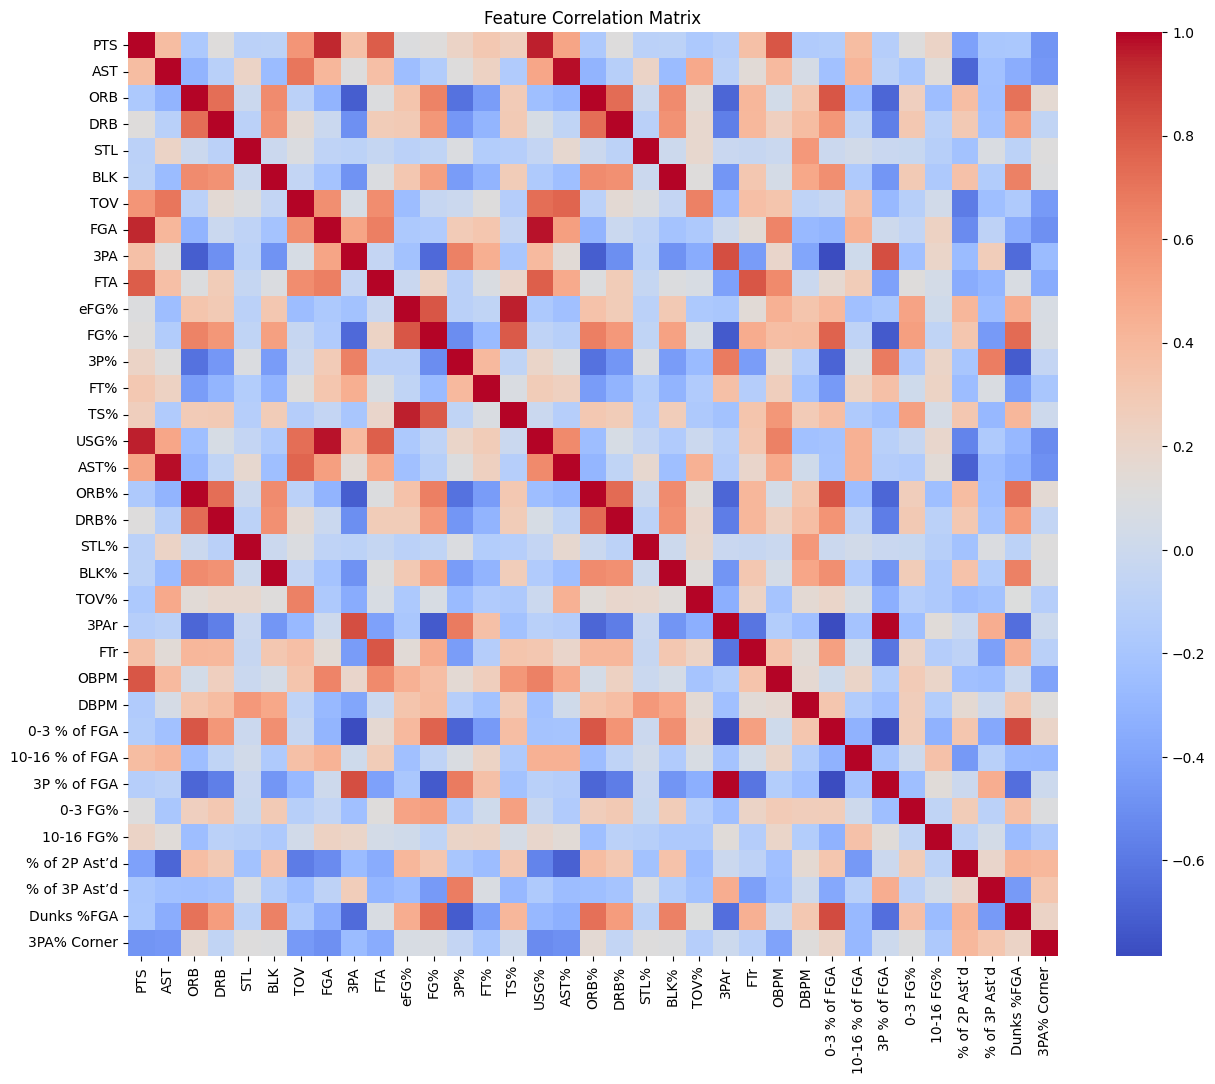

In [ ]:
corr_matrix = data.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Matrix")
plt.show()

In [144]:
selected_features = [
    "PTS",
    'USG%', 'AST', 'ORB', 'DRB', 'STL', 'BLK',
    'TOV%', "0-3 % of FGA", "% of 3P Ast’d",
]

## K-means

In [145]:
numeric = data.drop(["G", "MP"], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric.values)
data_scaled = pd.DataFrame(X_scaled, index=data.index, columns=numeric.columns)

In [ ]:
# selected_features = [
#     "PTS", "ORB", "DRB", "AST",
#     'USG%', 'AST%', 'ORB%', 'DRB%', 'STL%', 'BLK%',
#     'TS%', '3PA', '3PAr', 'FTr',
#     'TOV', 'OBPM', 'DBPM'
# ] 0.18432232468784607


# # shooting_features = [
# #     "0-3 % of FGA",
# #     "10-16 % of FGA",
# #     "3P % of FGA", "0-3 FG%",
# #     "10-16 FG%", "% of 2P Ast’d",
# #     "% of 3P Ast’d",
# #     "Dunks %FGA",
# #     "3PA% Corner"
# # ]

# # selected_features = [
# #     'USG%', 'AST%', 'ORB%', 'DRB%', 'STL%', 'BLK%',
# #     'TS%', 'TOV%',
# #     '0-3 % of FGA', '3P % of FGA',  # shot zone volume
# #     '0-3 FG%', '3P%',           # finishing + shooting efficiency
# #      "% of 3P Ast’d", '% of 2P Ast’d'
# # ]

# # selected_features = [
# #     "PTS",
# #     'USG%', 'AST%', 'ORB%', 'DRB%', 'STL%', 'BLK%',
# #     'TOV%', "0-3 % of FGA",
# # ] BEST!! : 0.24810040327521657


X_cluster = data_scaled[selected_features]

kmeans = KMeans(n_clusters=5, random_state=0)
clusters = kmeans.fit_predict(X_cluster)

print(silhouette_score(X_cluster, clusters))

data['cluster'] = clusters

0.2549624770640306


In [146]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

kmeans_2d = KMeans(n_clusters=7, random_state=0)
clusters_2d = kmeans_2d.fit_predict(X_pca)

data["cluster"] = clusters_2d

<Figure size 1200x600 with 0 Axes>

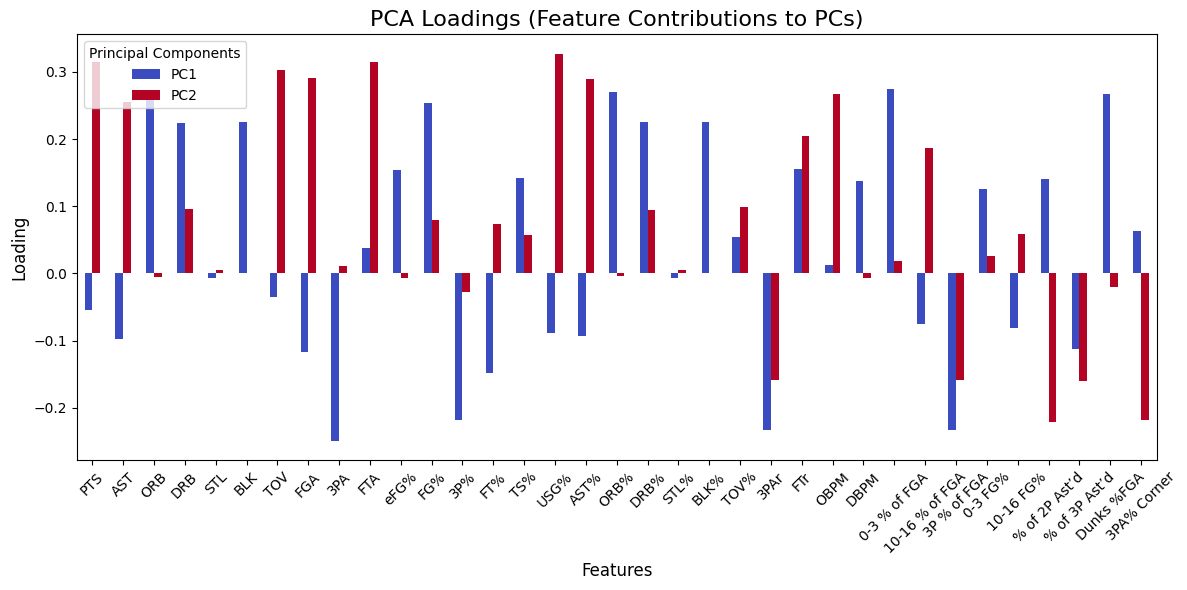

In [147]:
loadings = pca.components_.T

# Create a DataFrame for easy visualization
loadings_df = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(loadings.shape[1])], index=data_scaled.columns)  # Exclude 'cluster' column

# Plotting the PCA Loadings
plt.figure(figsize=(12, 6))

# Plot bars for the loadings of each feature on the two principal components
loadings_df.plot(kind='bar', figsize=(12, 6), cmap='coolwarm')
plt.title('PCA Loadings (Feature Contributions to PCs)', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Loading', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Principal Components', loc='upper left')
plt.tight_layout()
plt.show()

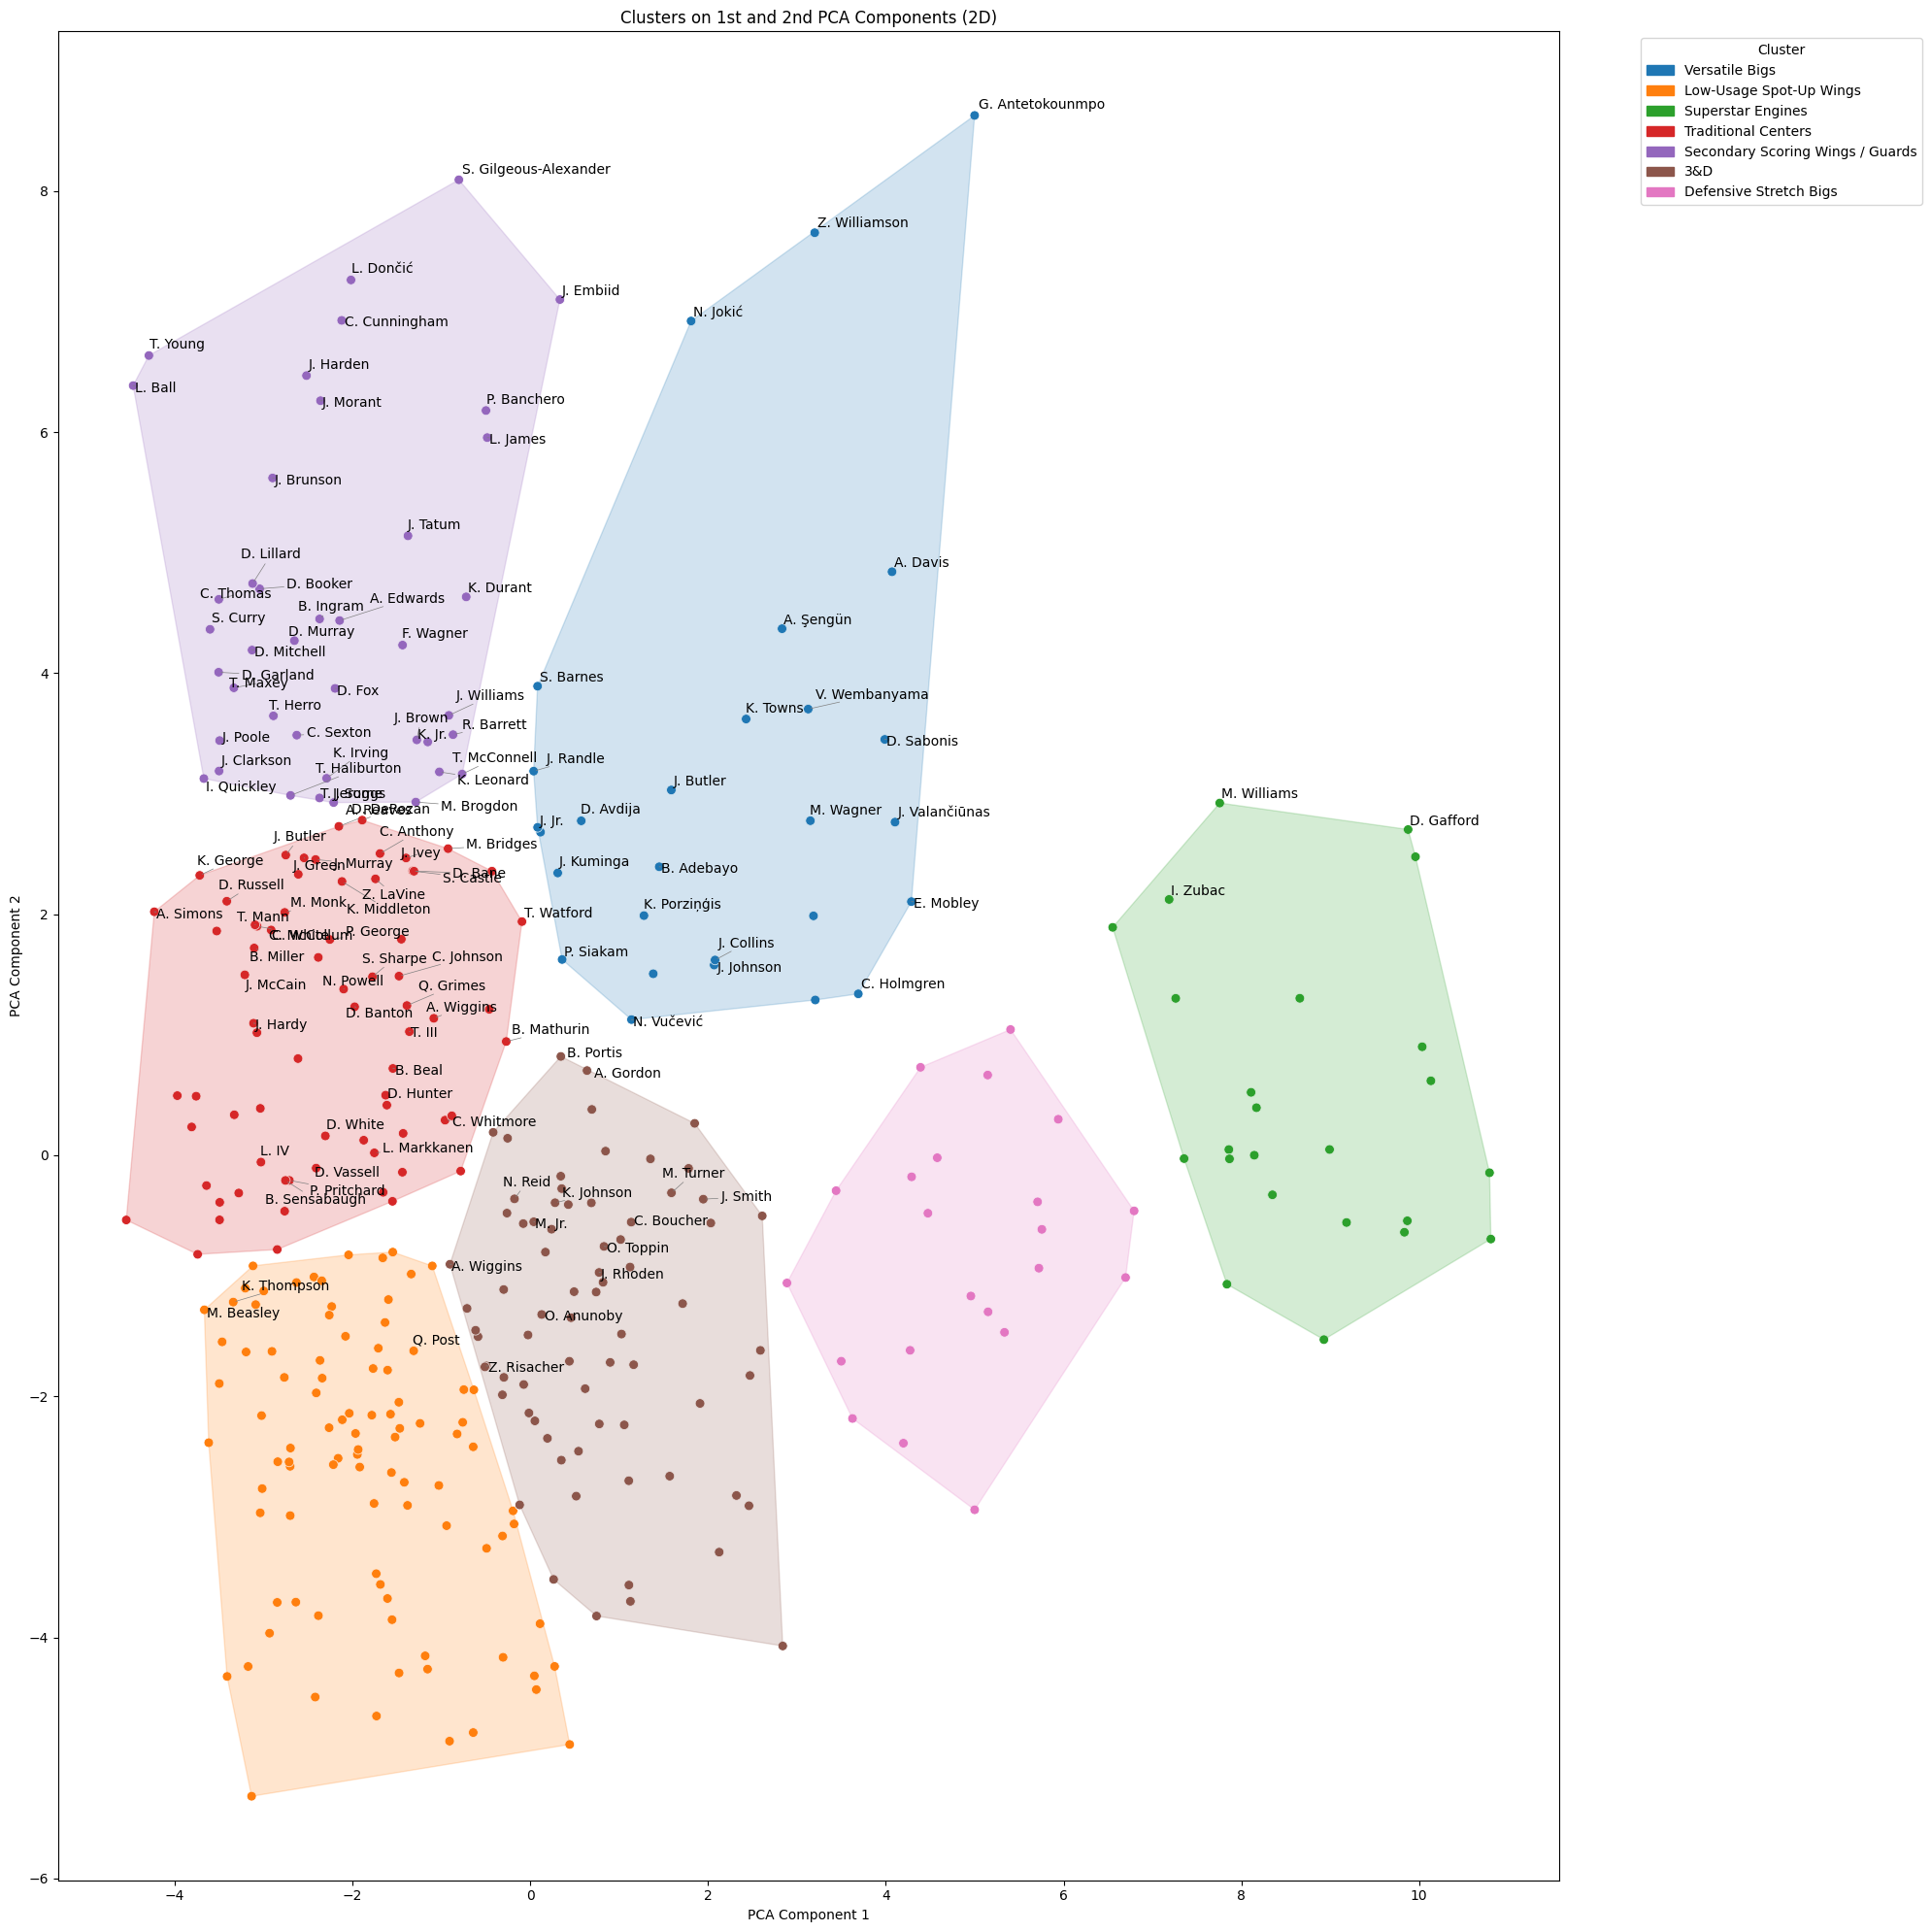

In [7]:
plt.figure(figsize=(20, 20))
unique_clusters = np.unique(clusters_2d)
palette = sns.color_palette('tab10', n_colors=len(unique_clusters))

ax = sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_2d, palette=palette, s=50, legend=False)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Clusters on 1st and 2nd PCA Components (2D)")

# Draw convex hulls for each cluster
for cluster_id in unique_clusters:
    points = X_pca[clusters_2d == cluster_id]
    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_pts = points[hull.vertices]
        polygon = plt.Polygon(hull_pts, color=palette[cluster_id], alpha=0.2)
        ax.add_patch(polygon)

# Annotate only top players by scoring
top_players = data.sort_values("PTS", ascending=False).head(125).index
texts = []

for i, player in enumerate(data.index):
    if player in top_players:
        parts = player.split()
        if len(parts) >= 2:
            label = f"{parts[0][0]}. {parts[-1]}"
        else:
            label = player
        texts.append(ax.text(X_pca[i, 0], X_pca[i, 1], label, fontsize=10))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

cluster_labels = ["Versatile Bigs", "Low-Usage Spot-Up Wings", "Superstar Engines", "Traditional Centers", "Secondary Scoring Wings / Guards", "3&D", "Defensive Stretch Bigs"]

# Custom Legend (labels were chosen after analysis of clusters)
patches = [
    mpatches.Patch(color=palette[i], label=cluster_labels[i])  # Use custom label here
    for i in unique_clusters
]
plt.legend(handles=patches, title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
data.groupby('cluster').mean().round(2).to_csv("clusters.csv")
pd.read_csv("clusters.csv")

,cluster,PTS,AST,ORB,DRB,STL,BLK,TOV,FGA,3PA,...,DBPM,0-3 % of FGA,10-16 % of FGA,3P % of FGA,0-3 FG%,10-16 FG%,% of 2P Ast’d,% of 3P Ast’d,Dunks %FGA,3PA% Corner
0,0,25.83,5.70,3.32,10.45,1.61,1.58,3.48,19.45,6.05,...,0.80,0.29,0.08,0.31,0.70,0.39,0.62,0.90,0.08,0.21
1,1,20.79,4.73,1.33,4.91,1.52,0.53,2.20,17.10,9.54,...,-0.59,0.16,0.08,0.56,0.66,0.42,0.58,0.89,0.03,0.28
2,2,36.17,9.50,1.41,7.02,1.76,0.70,4.57,26.96,10.19,...,-0.13,0.19,0.13,0.38,0.68,0.46,0.34,0.58,0.03,0.09
3,3,18.98,3.44,6.23,10.95,1.46,2.44,2.42,12.82,0.41,...,0.78,0.59,0.04,0.03,0.73,0.30,0.70,0.26,0.30,0.28
4,4,27.29,7.24,1.36,5.61,1.69,0.65,3.56,21.80,8.80,...,-0.65,0.18,0.12,0.40,0.68,0.42,0.40,0.76,0.03,0.18
5,5,16.81,3.50,2.09,5.92,1.88,0.99,1.87,13.83,7.07,...,0.39,0.22,0.05,0.52,0.69,0.37,0.65,0.96,0.06,0.39
6,6,18.78,3.69,4.40,9.31,1.78,1.90,2.30,14.69,3.83,...,0.79,0.39,0.09,0.26,0.71,0.40,0.69,0.95,0.16,0.40


In [ ]:
clusters.loc[(clusters["cluster"] == 1) | (clusters["cluster"] == 5)]

,cluster,PTS,AST,ORB,DRB,STL,BLK,TOV,FGA,3PA,...,DBPM,0-3 % of FGA,10-16 % of FGA,3P % of FGA,0-3 FG%,10-16 FG%,% of 2P Ast’d,% of 3P Ast’d,Dunks %FGA,3PA% Corner
1,1,20.79,4.73,1.33,4.91,1.52,0.53,2.20,17.10,9.54,...,-0.59,0.16,0.08,0.56,0.66,0.42,0.58,0.89,0.03,0.28
5,5,16.81,3.50,2.09,5.92,1.88,0.99,1.87,13.83,7.07,...,0.39,0.22,0.05,0.52,0.69,0.37,0.65,0.96,0.06,0.39


In [ ]:
data.loc[(data["cluster"] == 4)].index

Index(['DeMar DeRozan', 'Tyler Herro', 'Jalen Green', 'Austin Reaves',
       'Pascal Siakam', 'Tyrese Haliburton', 'Coby White', 'Jamal Murray',
       'Chris Paul', 'Anfernee Simons', 'Kevin Durant', 'Shaedon Sharpe',
       'Jalen Williams', 'Julius Randle', 'Jaren Jackson Jr.', 'Desmond Bane',
       'Stephon Castle', 'Jaylen Brown', 'Bennedict Mathurin',
       'Scottie Barnes', 'Keyonte George', 'Russell Westbrook', 'Malik Monk',
       'Miles Bridges', 'Norman Powell', 'RJ Barrett', 'Trey Murphy III',
       'Isaiah Collier', 'CJ McCollum', 'Kyrie Irving', 'Cameron Johnson',
       'Scoot Henderson', 'Collin Sexton', 'Bradley Beal', 'Scotty Pippen Jr.',
       'T.J. McConnell', 'Ty Jerome', 'Jose Alvarado', 'Paul George',
       'Cole Anthony', 'Kawhi Leonard', 'Jonathan Kuminga', 'Dalano Banton',
       'Cameron Payne', 'Jalen Suggs', 'Jordan Clarkson', 'Brandon Miller',
       'Immanuel Quickley', 'Trendon Watford', 'Jaden Hardy', 'Jaden Ivey',
       'Cam Whitmore', 'Jared Mc

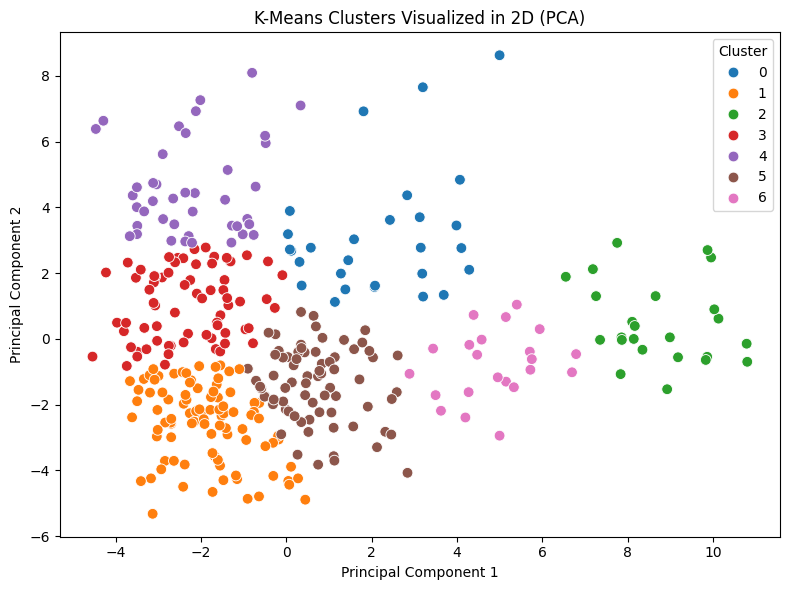

In [26]:
# Same graph as above just without player labels and polygons
df = data.copy(deep=True)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster', palette='tab10', s=60)
plt.title("K-Means Clusters Visualized in 2D (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

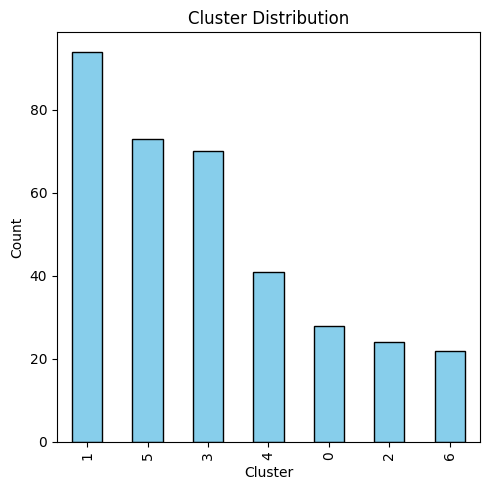

In [ ]:
cluster_counts = data['cluster'].value_counts()
plt.figure(figsize=(5, 5))
cluster_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Cluster Distribution')
plt.tight_layout()
plt.show()

## Agglomerative Clustering

The old filter had far too many players to properly display on the dendrogram so I cut the player count down further.

In [130]:
# More aggressive filter: 25 MPG and 40 Games Played
mask = ((data['MP'] / data['G']) >= 25) & (data['G'] >= 40)

removed_players = data[~mask].index.tolist()
data_dendro = data[mask].drop(["cluster"], axis=1)

print(f"Removed {len(removed_players)} players:")
for name in removed_players:
    print(name)

Removed 192 players:
Keon Ellis
Julian Champagnie
Keon Johnson
Anthony Black
Derrick Jones Jr.
Buddy Hield
Zaccharie Risacher
Keldon Johnson
Royce O'Neale
Haywood Highsmith
Duncan Robinson
Kris Dunn
Mike Conley
Amir Coffey
Aaron Wiggins
Scotty Pippen Jr.
A.J. Green
Peyton Watson
Moses Moody
Tristan Da Silva
Isaiah Joe
Miles McBride
Obi Toppin
Grayson Allen
Sam Hauser
Ziaire Williams
Gabe Vincent
Kyle Filipowski
Matas Buzelis
Dalton Knecht
Luke Kennard
Jamal Shead
Isaiah Stewart
Brice Sensabaugh
Goga Bitadze
Kel'el Ware
Tari Eason
Zach Edey
T.J. McConnell
Ryan Dunn
Sam Merrill
Ty Jerome
Julian Strawther
Nick Smith Jr.
Jaime Jaquez Jr.
Nicolas Batum
Jose Alvarado
Luke Kornet
Trey Lyles
Justin Champagnie
Ausar Thompson
Donovan Clingan
Jordan Hawkins
Tyrese Martin
Mason Plumlee
Jonathan Mogbo
Jalen Johnson
Johnny Juzang
Ron Holland
Dean Wade
Ricky Council IV
Tidjane Salaün
Moussa Diabaté
Jeremiah Robinson-Earl
Simone Fontecchio
Cole Anthony
Ben Sheppard
Daniel Gafford
Brandon Clarke
Jarace

In [131]:
data_dendro.shape

(160, 37)

With the dataset much smaller, we must rescale the data before running the AgglomerativeClustering algorithm

In [132]:
numeric = data_dendro.drop(["G", "MP"], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric.values)
data_scaled = pd.DataFrame(X_scaled, index=data_dendro.index, columns=numeric.columns)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(data_scaled[selected_features])

In [133]:
n_clusters = 10

agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = agg_clustering.fit_predict(X_pca)
data_dendro["dendro_cluster"] = cluster_labels

Now let's plot the dendrogram to visualize these clusters and similarities

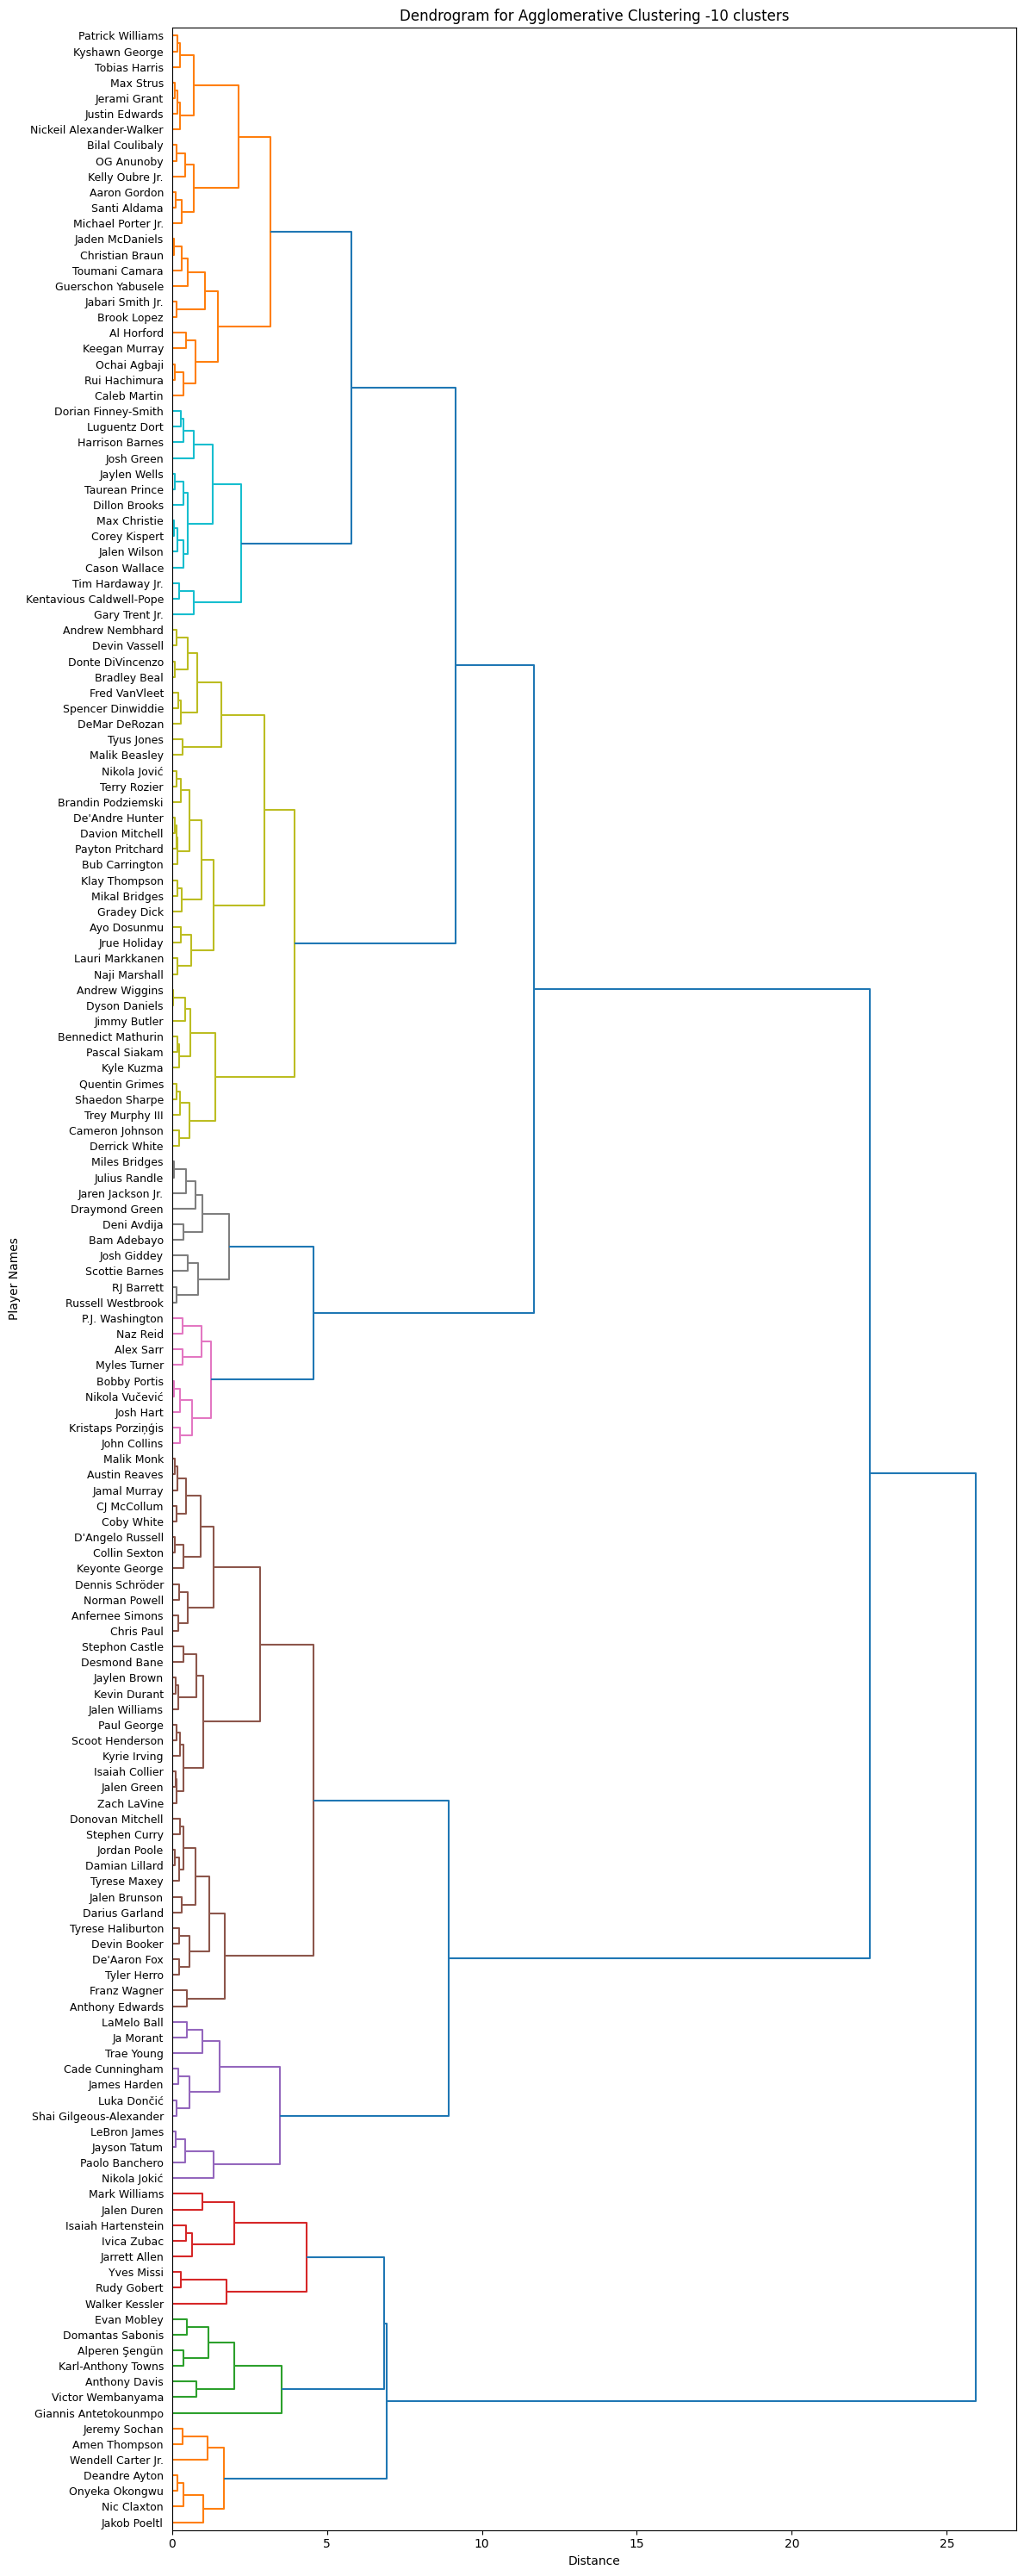

In [123]:
# Create linkage matrix for dendrogram
linkage_matrix = sch.linkage(X_pca, method='ward')

# Get distance threshold that gives exactly n_clusters
threshold = linkage_matrix[-(n_clusters - 1), 2]

# Plot dendrogram with exactly n_clusters colors and with player names as indexes
plt.figure(figsize=(12, 30))
sch.dendrogram(
    linkage_matrix,
    labels=data_scaled.index.tolist(),
    orientation='right',
    color_threshold=threshold,
    leaf_font_size=9
)

plt.title(f"Dendrogram for Agglomerative Clustering -{n_clusters} clusters")
plt.xlabel("Distance")
plt.ylabel("Player Names")
plt.tight_layout()
plt.show()

In [125]:
data_dendro.groupby('dendro_cluster')[selected_features].mean().round(2).sort_index()

,PTS,USG%,AST,ORB,DRB,STL,BLK,TOV%,0-3 % of FGA,% of 3P Ast’d
dendro_cluster,,,,,,,,,,
0,30.06,26.07,8.03,0.95,5.17,1.68,0.51,12.57,0.16,0.65
1,23.80,20.44,5.62,1.42,5.32,1.61,0.58,11.01,0.17,0.85
2,21.18,16.36,3.90,5.76,12.02,1.21,2.22,13.30,0.58,0.12
3,33.56,27.77,6.44,4.01,12.89,1.43,2.23,12.56,0.36,0.86
4,26.83,24.49,7.65,2.38,8.52,1.74,1.11,15.17,0.25,0.88
5,36.88,32.15,11.06,1.37,7.96,1.83,0.75,13.86,0.18,0.52
6,21.29,17.81,4.17,4.66,9.56,1.64,1.69,12.80,0.44,0.99
7,19.65,16.68,3.60,2.14,6.12,1.47,1.03,10.37,0.24,0.95
8,17.64,14.76,3.03,1.39,4.23,1.51,0.44,9.36,0.16,0.96


In [127]:
data_dendro.groupby('dendro_cluster').mean().round(2)

,PTS,AST,ORB,DRB,STL,BLK,TOV,FGA,3PA,FTA,...,DBPM,0-3 % of FGA,10-16 % of FGA,3P % of FGA,0-3 FG%,10-16 FG%,% of 2P Ast’d,% of 3P Ast’d,Dunks %FGA,3PA% Corner
dendro_cluster,,,,,,,,,,,,,,,,,,,,,
0,30.06,8.03,0.95,5.17,1.68,0.51,3.65,23.28,10.25,6.13,...,-0.79,0.16,0.12,0.44,0.69,0.45,0.36,0.65,0.02,0.13
1,23.80,5.62,1.42,5.32,1.61,0.58,2.49,18.88,8.99,4.19,...,-0.42,0.17,0.10,0.48,0.69,0.44,0.52,0.85,0.03,0.26
2,21.18,3.90,5.76,12.02,1.21,2.22,2.46,13.95,0.22,5.14,...,0.95,0.58,0.06,0.02,0.74,0.36,0.72,0.12,0.31,0.13
3,33.56,6.44,4.01,12.89,1.43,2.23,3.90,23.79,4.91,8.70,...,1.63,0.36,0.09,0.21,0.74,0.41,0.58,0.86,0.12,0.08
4,26.83,7.65,2.38,8.52,1.74,1.11,4.10,21.10,7.09,6.52,...,0.56,0.25,0.10,0.34,0.67,0.41,0.50,0.88,0.05,0.25
5,36.88,11.06,1.37,7.96,1.83,0.75,5.05,27.44,10.45,9.40,...,0.49,0.18,0.13,0.38,0.69,0.46,0.31,0.52,0.03,0.07
6,21.29,4.17,4.66,9.56,1.64,1.69,2.64,15.94,2.16,4.33,...,0.81,0.44,0.10,0.14,0.75,0.46,0.71,0.99,0.17,0.44
7,19.65,3.60,2.14,6.12,1.47,1.03,1.97,15.69,7.42,3.08,...,-0.19,0.24,0.07,0.48,0.70,0.39,0.64,0.95,0.07,0.32
8,17.64,3.03,1.39,4.23,1.51,0.44,1.53,14.16,8.44,2.41,...,-0.17,0.16,0.06,0.60,0.66,0.43,0.64,0.96,0.03,0.36


# Other stuff

In [ ]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.cumsum())

[0.3026186  0.21551064 0.11233302 0.07472938 0.0489598  0.04134938
 0.03463192 0.02967985 0.02392317 0.01933163 0.01626475 0.01463875
 0.01339437 0.01080898]
[0.3026186  0.51812923 0.63046225 0.70519163 0.75415143 0.79550081
 0.83013273 0.85981259 0.88373575 0.90306739 0.91933213 0.93397088
 0.94736525 0.95817423]


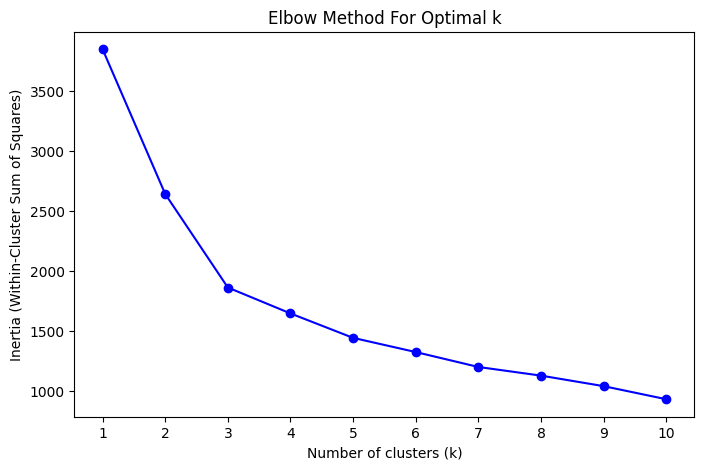

In [ ]:
inertia = []
k_range = range(1, 11)  # try k=1 to 10
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
for k in k_range:

    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_pca)

    inertia.append(kmeans.inertia_)

# 3. Plot
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method For Optimal k')
plt.xticks(k_range)
plt.show()

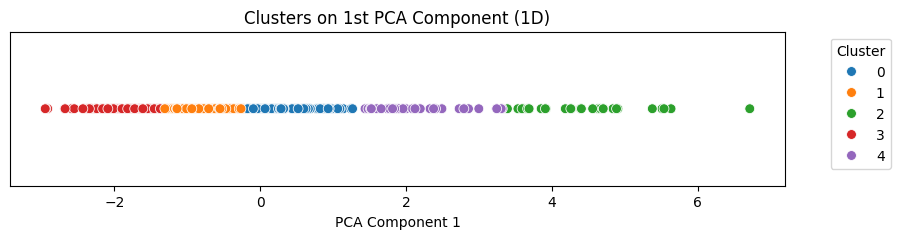

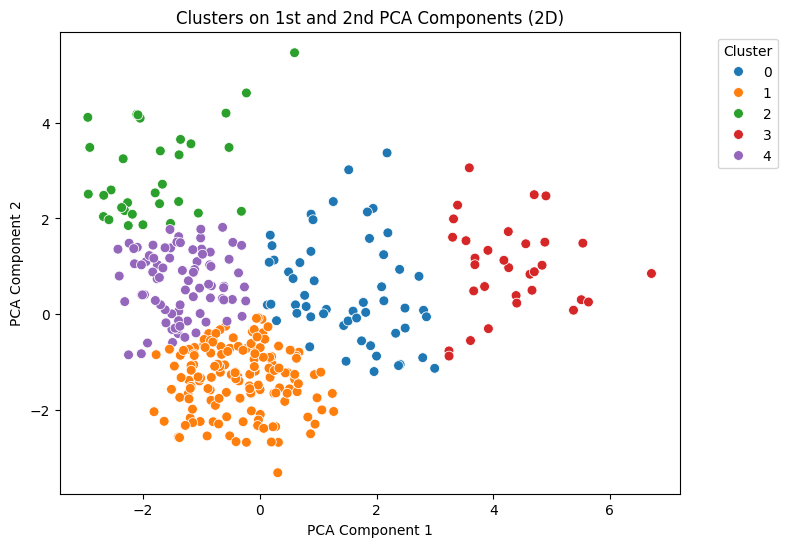

In [ ]:
selected_features = [
    "PTS",
    'USG%', 'AST%', 'ORB%', 'DRB%', 'STL%', 'BLK%',
    'TOV%', "0-3 % of FGA", "% of 3P Ast’d",
]

# 1. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[selected_features])

# 2. Apply PCA (we'll get at least 2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Cluster on first PCA component only (1D clustering)
kmeans_1d = KMeans(n_clusters=5, random_state=0)
clusters_1d = kmeans_1d.fit_predict(X_pca[:, 0].reshape(-1, 1))

# 4. Cluster on first two PCA components (2D clustering)
kmeans_2d = KMeans(n_clusters=5, random_state=0)
clusters_2d = kmeans_2d.fit_predict(X_pca)

# 5. Plot 1D clusters along PC1
plt.figure(figsize=(10, 2))
sns.scatterplot(x=X_pca[:, 0], y=[0]*len(X_pca), hue=clusters_1d, palette='tab10', s=50)
plt.xlabel('PCA Component 1')
plt.yticks([])
plt.title('Clusters on 1st PCA Component (1D)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 6. Plot 2D clusters on PC1 vs PC2
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_2d, palette='tab10', s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters on 1st and 2nd PCA Components (2D)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


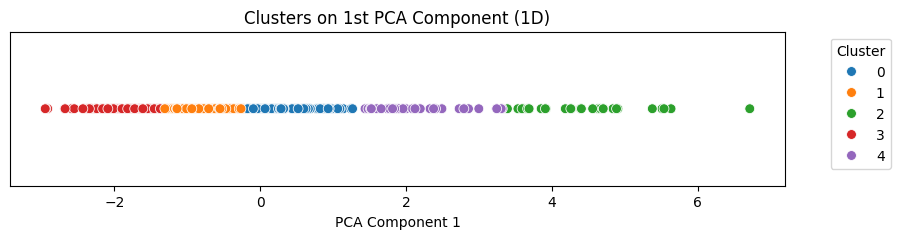

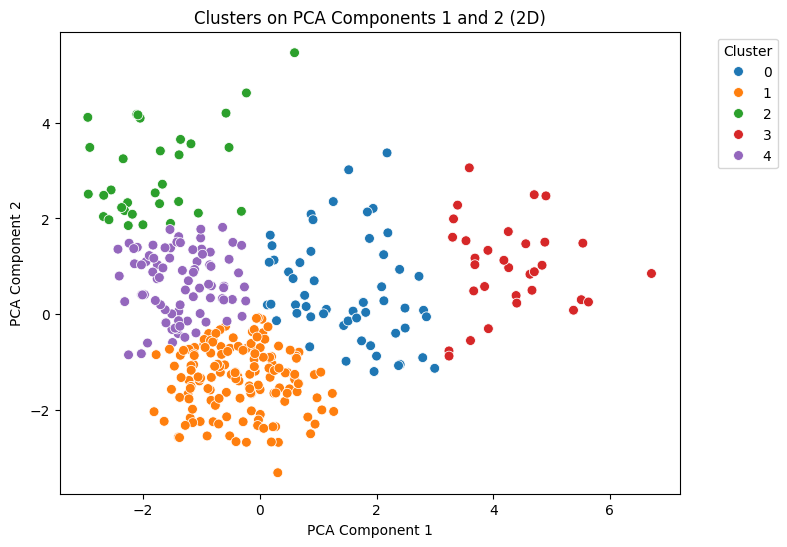

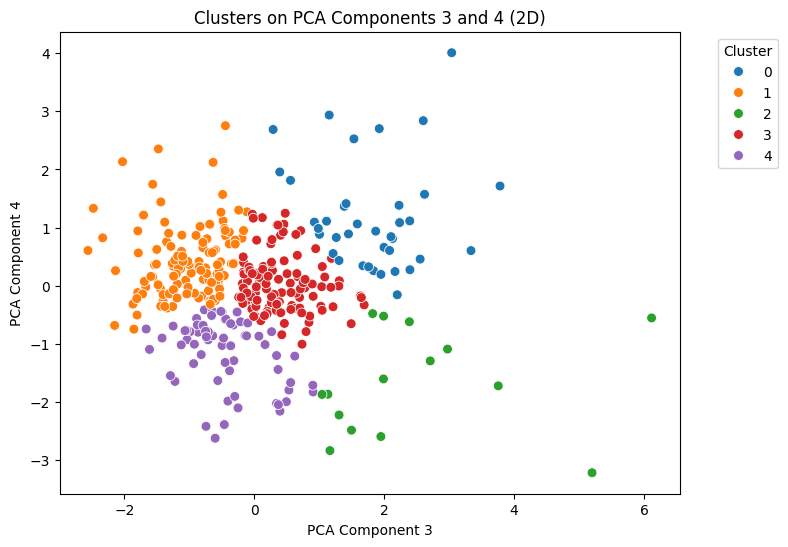

PC1: 33.19% of variance
PC2: 24.39% of variance
PC3: 14.49% of variance
PC4: 9.54% of variance


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Select features ---
selected_features = [
    "PTS",
    'USG%', 'AST%', 'ORB%', 'DRB%', 'STL%', 'BLK%',
    'TOV%', "0-3 % of FGA", "% of 3P Ast’d",
]

# --- 2. Scale the data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[selected_features])

# --- 3. PCA (4 components) ---
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

# --- 4. Cluster on PC1 (1D) ---
kmeans_1d = KMeans(n_clusters=5, random_state=0)
clusters_1d = kmeans_1d.fit_predict(X_pca[:, 0].reshape(-1, 1))

# --- 5. Cluster on PC1 + PC2 (2D) ---
kmeans_2d = KMeans(n_clusters=5, random_state=0)
clusters_2d = kmeans_2d.fit_predict(X_pca[:, :2])

# --- 6. Cluster on PC3 + PC4 (2D) ---
kmeans_34 = KMeans(n_clusters=5, random_state=0)
clusters_34 = kmeans_34.fit_predict(X_pca[:, 2:4])

# --- 7. Visualize PC1 Clustering (1D) ---
plt.figure(figsize=(10, 2))
sns.scatterplot(x=X_pca[:, 0], y=[0]*len(X_pca), hue=clusters_1d, palette='tab10', s=50)
plt.xlabel('PCA Component 1')
plt.yticks([])
plt.title('Clusters on 1st PCA Component (1D)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# --- 8. Visualize PC1 vs PC2 Clustering (2D) ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_2d, palette='tab10', s=50)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clusters on PCA Components 1 and 2 (2D)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# --- 9. Visualize PC3 vs PC4 Clustering (2D) ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 2], y=X_pca[:, 3], hue=clusters_34, palette='tab10', s=50)
plt.xlabel('PCA Component 3')
plt.ylabel('PCA Component 4')
plt.title('Clusters on PCA Components 3 and 4 (2D)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# --- 10. View PCA variance explained ---
explained = pca.explained_variance_ratio_
for i, var in enumerate(explained, 1):
    print(f"PC{i}: {var*100:.2f}% of variance")


In [ ]:
for i, var in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {var*100:.2f}% variance")


PC1: 33.19% variance
PC2: 24.39% variance


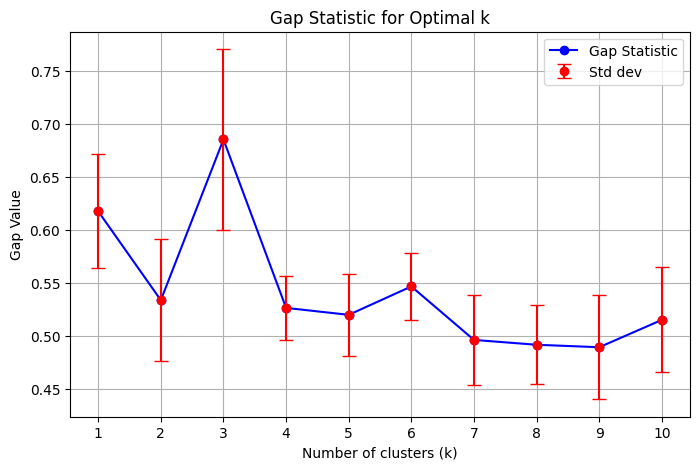

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt

def compute_dispersion(X, k):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    clusters = kmeans.predict(X)
    centers = kmeans.cluster_centers_
    dispersion = 0
    for i in range(k):
        cluster_points = X[clusters == i]
        if len(cluster_points) > 0:
            dispersion += np.sum(np.square(cluster_points - centers[i]))
    return dispersion

def gap_statistic(X, k_max=10, n_refs=10):
    shape = X.shape
    gaps = []
    stds = []
    log_wks = []
    log_wkbs = []

    # Create bounds for reference datasets
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    for k in range(1, k_max + 1):
        # Wk for original data
        wk = compute_dispersion(X, k)
        log_wks.append(np.log(wk))

        # Wk* for B reference datasets
        wkb = []
        for _ in range(n_refs):
            X_ref = np.random.uniform(mins, maxs, size=shape)
            wkb.append(np.log(compute_dispersion(X_ref, k)))
        gap = np.mean(wkb) - np.log(wk)
        std = np.std(wkb) * np.sqrt(1 + 1 / n_refs)

        gaps.append(gap)
        stds.append(std)
        log_wkbs.append(np.mean(wkb))

    return np.array(gaps), np.array(stds), log_wks

# === YOUR PCA + GAP RUN ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

gaps, stds, log_wks = gap_statistic(X_pca, k_max=10, n_refs=10)

# === Plot ===
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), gaps, 'bo-', label='Gap Statistic')
plt.errorbar(range(1, 11), gaps, yerr=stds, fmt='o', color='red', capsize=5, label='Std dev')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Gap Value')
plt.title('Gap Statistic for Optimal k')
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True)
plt.show()


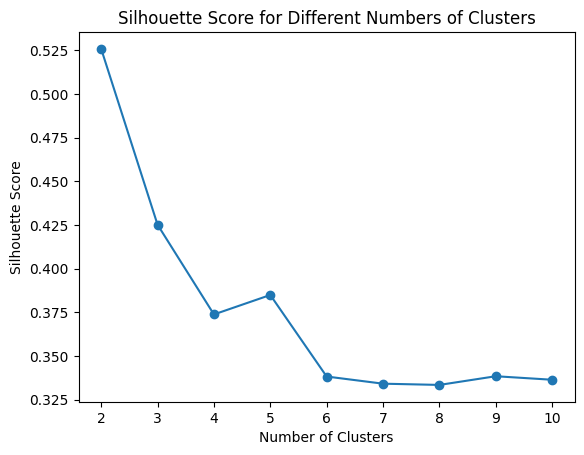

Best number of clusters: 2


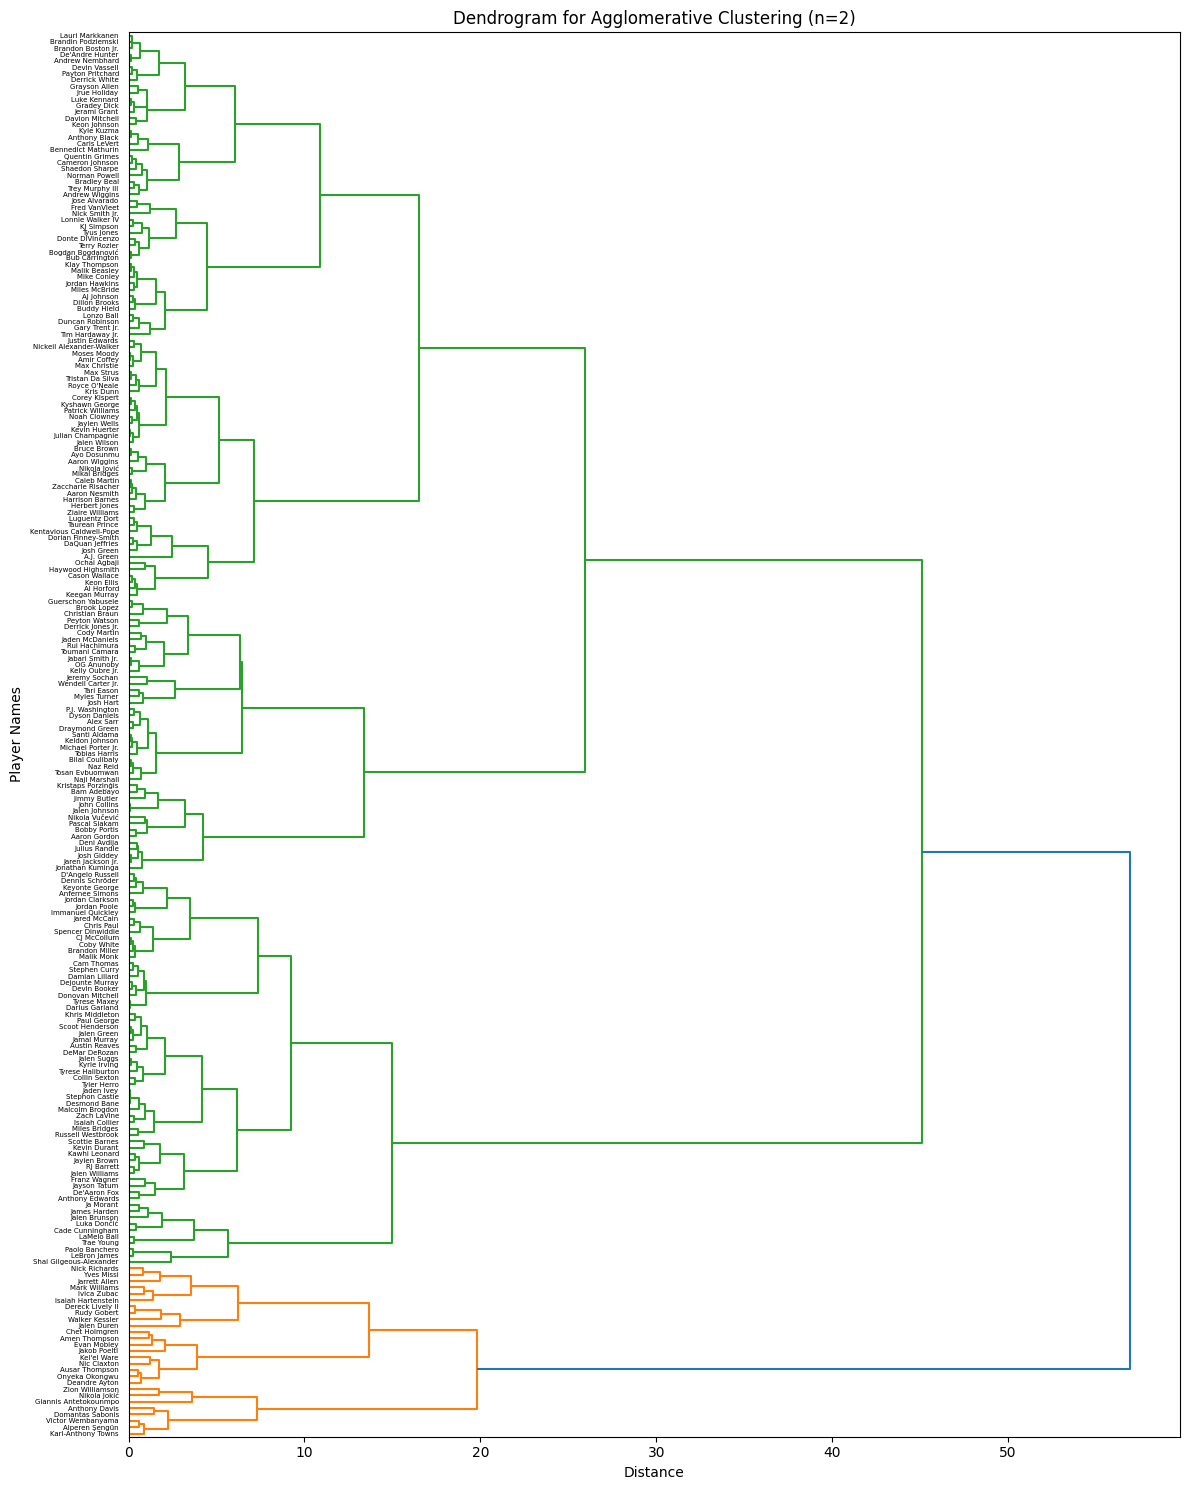

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
import numpy as np

# Assuming `data_scaled` and `selected_features` are already defined
# Step 1: PCA for dimensionality reduction (keeping it to 2D for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(data_scaled)

# Step 2: Calculate Silhouette Scores for different `n_clusters` values
silhouette_scores = []
range_n_clusters = range(2, 11)  # Check for cluster sizes from 2 to 10 (or whatever range you prefer)

for n_clusters in range_n_clusters:
    # Perform Agglomerative Clustering
    agg_clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    cluster_labels = agg_clustering.fit_predict(X_pca)

    # Compute Silhouette Score
    score = silhouette_score(X_pca, cluster_labels)
    silhouette_scores.append(score)

# Step 3: Plot Silhouette Scores to identify the best number of clusters
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.show()

# Best number of clusters based on Silhouette Score
best_n_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"Best number of clusters: {best_n_clusters}")

# Step 4: Generate the Dendrogram for the best number of clusters
agg_clustering = AgglomerativeClustering(n_clusters=best_n_clusters, linkage='ward')
cluster_labels = agg_clustering.fit_predict(X_pca)

linkage_matrix = sch.linkage(X_pca, method='ward')

# Step 5: Create Dendrogram plot
plt.figure(figsize=(12, 15))
sch.dendrogram(
    linkage_matrix,
    labels=data.index.tolist(),      # player names as labels
    orientation='right',
    color_threshold=linkage_matrix[-(best_n_clusters - 1), 2]  # Color threshold for `best_n_clusters`
)
plt.title(f'Dendrogram for Agglomerative Clustering (n={best_n_clusters})')
plt.xlabel('Distance')
plt.ylabel('Player Names')
plt.tight_layout()
plt.show()

# Step 6: Save dendrogram-based clusters to DataFrame
data['dendro_cluster'] = cluster_labels
